In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
from google.colab import files
uploaded = files.upload()

Saving breast_cancer_dataset.csv to breast_cancer_dataset (1).csv


In [7]:
data = load_breast_cancer()

# Convert to DataFrame
breast_cancer_dataset = pd.DataFrame(
    data.data, columns=data.feature_names
)

# Add target column
breast_cancer_dataset['target'] = data.target

print("Dataset Shape:", breast_cancer_dataset.shape)
print(breast_cancer_dataset.head())

Dataset Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [8]:
X = breast_cancer_dataset.drop('target', axis=1).values
y = breast_cancer_dataset['target'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def compute_loss(y, y_pred):
    epsilon = 1e-9
    return -np.mean(
        y * np.log(y_pred + epsilon) +
        (1 - y) * np.log(1 - y_pred + epsilon)
    )

In [13]:
def train_logistic_regression(X, y, lr=0.01, epochs=1000):
    m, n = X.shape

    weights = np.zeros(n)
    bias = 0

    for i in range(epochs):
        linear = np.dot(X, weights) + bias
        y_pred = sigmoid(linear)

        # gradients
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        # update
        weights -= lr * dw
        bias -= lr * db

        if i % 100 == 0:
            loss = compute_loss(y, y_pred)
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return weights, bias

In [14]:
w_manual, b_manual = train_logistic_regression(X_train, y_train)
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= 0.5).astype(int)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2522
Epoch 200, Loss: 0.1897
Epoch 300, Loss: 0.1615
Epoch 400, Loss: 0.1448
Epoch 500, Loss: 0.1336
Epoch 600, Loss: 0.1253
Epoch 700, Loss: 0.1190
Epoch 800, Loss: 0.1139
Epoch 900, Loss: 0.1097


In [15]:
y_pred_manual = predict(X_test, w_manual, b_manual)

accuracy_manual = np.mean(y_pred_manual == y_test)

print("\n✅ Manual Model Accuracy:", accuracy_manual)
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

accuracy_sklearn = model.score(X_test, y_test)

print("✅ Sklearn Model Accuracy:", accuracy_sklearn)


✅ Manual Model Accuracy: 0.9912280701754386
✅ Sklearn Model Accuracy: 0.9736842105263158


In [16]:
print("\n🔍 Weight Comparison (first 5 features):")
print("Manual Weights:", w_manual[:5])
print("Sklearn Coefficients:", model.coef_[0][:5])

print("\nBias Comparison:")
print("Manual Bias:", b_manual)
print("Sklearn Intercept:", model.intercept_)


🔍 Weight Comparison (first 5 features):
Manual Weights: [-0.37522937 -0.36006938 -0.37107979 -0.37113421 -0.15591433]
Sklearn Coefficients: [-0.43464701 -0.39719369 -0.39606985 -0.46999027 -0.06739432]

Bias Comparison:
Manual Bias: 0.3265103861459602
Sklearn Intercept: [0.32857199]


In [17]:
X2 = X[:, :2]
y2 = y

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

w2, b2 = train_logistic_regression(X2_train, y2_train, lr=0.1, epochs=1000)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.3258
Epoch 200, Loss: 0.2926
Epoch 300, Loss: 0.2812
Epoch 400, Loss: 0.2759
Epoch 500, Loss: 0.2730
Epoch 600, Loss: 0.2713
Epoch 700, Loss: 0.2702
Epoch 800, Loss: 0.2695
Epoch 900, Loss: 0.2691


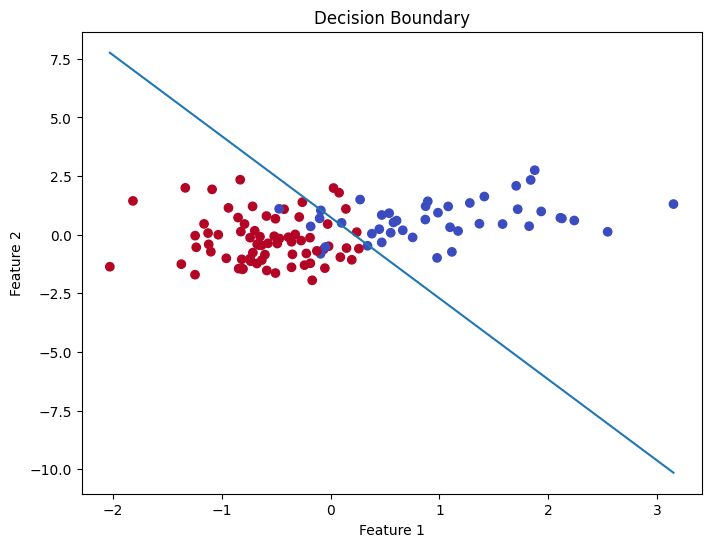

In [18]:
def plot_decision_boundary(X, y, w, b):
    plt.figure(figsize=(8,6))

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    x2 = -(w[0]*x1 + b) / w[1]

    plt.plot(x1, x2)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(X2_test, y2_test, w2, b2)

In [19]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

In [20]:
model_ovr = LogisticRegression(multi_class='ovr', max_iter=200)
model_ovr.fit(X_iris, y_iris)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='ovr')

In [21]:
predictions = model_ovr.predict(X_iris)
probabilities = model_ovr.predict_proba(X_iris)

print("\n🌸 First 10 Predictions:")
print(predictions[:10])

print("\n🌸 First 5 Probability Outputs:")
print(probabilities[:5])


🌸 First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

🌸 First 5 Probability Outputs:
[[8.96813456e-01 1.03185472e-01 1.07194623e-06]
 [7.78984138e-01 2.21014550e-01 1.31163851e-06]
 [8.34873009e-01 1.65125977e-01 1.01427196e-06]
 [7.90013297e-01 2.09984797e-01 1.90590562e-06]
 [9.12057221e-01 8.79417044e-02 1.07481744e-06]]


In [22]:
import pickle

# Save model
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("✅ Model saved as logistic_model.pkl")

✅ Model saved as logistic_model.pkl


In [23]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("✅ Scaler saved as scaler.pkl")

✅ Scaler saved as scaler.pkl


In [24]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>